# IMPORTANDO

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    classification_report,
    confusion_matrix
)

from imblearn.under_sampling import RandomUnderSampler

# Oculta avisos futuros do Seaborn/Pandas que não representam erros.
warnings.filterwarnings('ignore', category=FutureWarning)

# Constantes para garantir reprodutibilidade.
RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda valor: f'{valor:,.4f}')

sns.set_theme(style='whitegrid')

Nesta etapa foram importadas as bibliotecas necessárias para manipulação dos dados, visualização, preparação das variáveis, balanceamento e modelagem. O valor random_state=42 será utilizado para garantir que as divisões, amostragens e resultados possam ser reproduzidos durante a correção do projeto.

In [2]:
# O arquivo CSV deve ficar na mesma pasta do notebook.
DATA_PATH = Path('credit_risk_dataset.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Arquivo 'credit_risk_dataset.csv' não encontrado. "
        "Coloque o CSV na mesma pasta do notebook."
    )

# Mantemos uma versão original da base para a EDA.
df_raw = pd.read_csv(DATA_PATH)

print(
    f'Dataset carregado: '
    f'{df_raw.shape[0]:,} linhas e {df_raw.shape[1]} colunas.'
)

display(df_raw.head())

Dataset carregado: 32,581 linhas e 12 colunas.


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3
1,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2
2,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3
3,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2
4,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4


O dataset foi carregado por meio da biblioteca Pandas. A base original foi armazenada em df_raw, preservando os dados antes das transformações. Também foi implementada uma verificação para informar claramente caso o arquivo CSV não esteja na mesma pasta do notebook.

# VIZUALIZANDO DATASET

In [4]:
print('DIMENSÃO DA BASE')
print(f'Linhas: {df_raw.shape[0]:,}')
print(f'Colunas: {df_raw.shape[1]}')

print('\nTIPOS E VALORES NÃO NULOS')
df_raw.info()

print('\nESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS')
display(
    df_raw.describe().T
)

print('\nESTATÍSTICAS DESCRITIVAS — VARIÁVEIS CATEGÓRICAS')

colunas_categoricas_eda = df_raw.select_dtypes(
    include=['str', 'category']
).columns

if len(colunas_categoricas_eda) > 0:
    display(
        df_raw[colunas_categoricas_eda]
        .describe()
        .T
    )
else:
    print('Nenhuma variável categórica foi encontrada.')

qualidade_dados = pd.DataFrame({
    'tipo': df_raw.dtypes.astype(str),
    'nulos': df_raw.isna().sum(),
    'nulos_%': (
        df_raw.isna().mean() * 100
    ).round(2),
    'valores_unicos': df_raw.nunique(
        dropna=False
    )
})

print('\nQUALIDADE DOS DADOS')
display(qualidade_dados)

quantidade_duplicadas = (
    df_raw.duplicated().sum()
)

print(
    f'\nLinhas duplicadas exatas encontradas: '
    f'{quantidade_duplicadas:,}'
)

DIMENSÃO DA BASE
Linhas: 32,581
Colunas: 12

TIPOS E VALORES NÃO NULOS
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str

,count,mean,std,min,25%,50%,75%,max
person_age,"32,581.0000",27.7346,6.3481,20.0000,23.0000,26.0000,30.0000,144.0000
person_income,"32,581.0000","66,074.8485","61,983.1192","4,000.0000","38,500.0000","55,000.0000","79,200.0000","6,000,000.0000"
person_emp_length,"31,686.0000",4.7897,4.1426,0.0000,2.0000,4.0000,7.0000,123.0000
loan_amnt,"32,581.0000","9,589.3711","6,322.0866",500.0000,"5,000.0000","8,000.0000","12,200.0000","35,000.0000"
loan_int_rate,"29,465.0000",11.0117,3.2405,5.4200,7.9000,10.9900,13.4700,23.2200
loan_status,"32,581.0000",0.2182,0.4130,0.0000,0.0000,0.0000,0.0000,1.0000
loan_percent_income,"32,581.0000",0.1702,0.1068,0.0000,0.0900,0.1500,0.2300,0.8300
cb_person_cred_hist_length,"32,581.0000",5.8042,4.0550,2.0000,3.0000,4.0000,8.0000,30.0000



ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS CATEGÓRICAS


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836



QUALIDADE DOS DADOS


,tipo,nulos,nulos_%,valores_unicos
person_age,int64,0,0.0000,58
person_income,int64,0,0.0000,4295
person_home_ownership,str,0,0.0000,4
person_emp_length,float64,895,2.7500,37
loan_intent,str,0,0.0000,6
loan_grade,str,0,0.0000,7
loan_amnt,int64,0,0.0000,753
loan_int_rate,float64,3116,9.5600,349
loan_status,int64,0,0.0000,2
loan_percent_income,float64,0,0.0000,77



Linhas duplicadas exatas encontradas: 165


Nesta análise inicial foram exibidas as dimensões do dataset, os tipos das variáveis, a quantidade de registros não nulos e as estatísticas descritivas. As variáveis numéricas e categóricas foram analisadas separadamente. Também foram calculados o total e o percentual de valores ausentes, a quantidade de valores únicos e o número de linhas duplicadas. A seleção das variáveis categóricas com exclude='number' evita incompatibilidades entre diferentes versões do Pandas.

# GRAFICOS

DISTRIBUIÇÃO DA VARIÁVEL-ALVO


,quantidade,percentual_%
loan_status,,
0,25473,78.1800
1,7108,21.8200


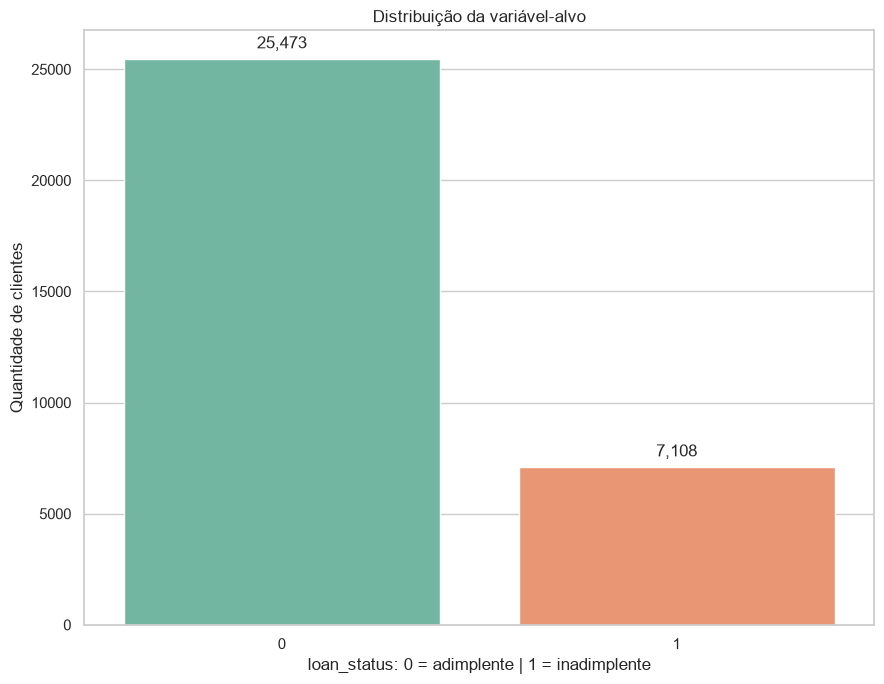

In [6]:
contagem_alvo = (
    df_raw['loan_status']
    .value_counts()
    .sort_index()
)

percentual_alvo = (
    df_raw['loan_status']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

distribuicao_alvo = pd.DataFrame({
    'quantidade': contagem_alvo,
    'percentual_%': percentual_alvo.round(2)
})

print('DISTRIBUIÇÃO DA VARIÁVEL-ALVO')
display(distribuicao_alvo)

plt.figure(figsize=(9, 7))

ax = sns.countplot(
    data=df_raw,
    x='loan_status',
    hue='loan_status',
    palette='Set2',
    legend=False
)

for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height()):,}',
        (
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.title('Distribuição da variável-alvo')
plt.xlabel('loan_status: 0 = adimplente | 1 = inadimplente')
plt.ylabel('Quantidade de clientes')
plt.tight_layout()
plt.show()

O gráfico demonstra que a variável-alvo apresenta desbalanceamento, pois existem mais clientes da classe 0, considerados adimplentes, do que clientes da classe 1, considerados inadimplentes. Dessa forma, a acurácia isolada não será suficiente para avaliar os modelos, pois um algoritmo poderia obter uma acurácia elevada apenas por favorecer a classe majoritária.

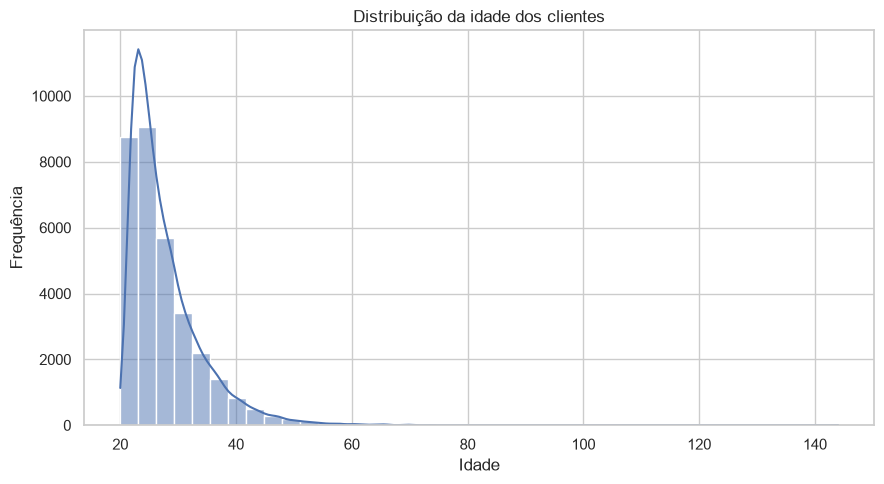

In [15]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_raw,
    x='person_age',
    bins=40,
    kde=True
)

plt.title('Distribuição da idade dos clientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

O histograma permite analisar a distribuição da idade dos clientes. A maior concentração ocorre nas faixas etárias mais jovens, enquanto alguns valores extremamente elevados indicam possíveis registros inconsistentes. Esses casos serão avaliados durante a etapa de tratamento e limpeza.

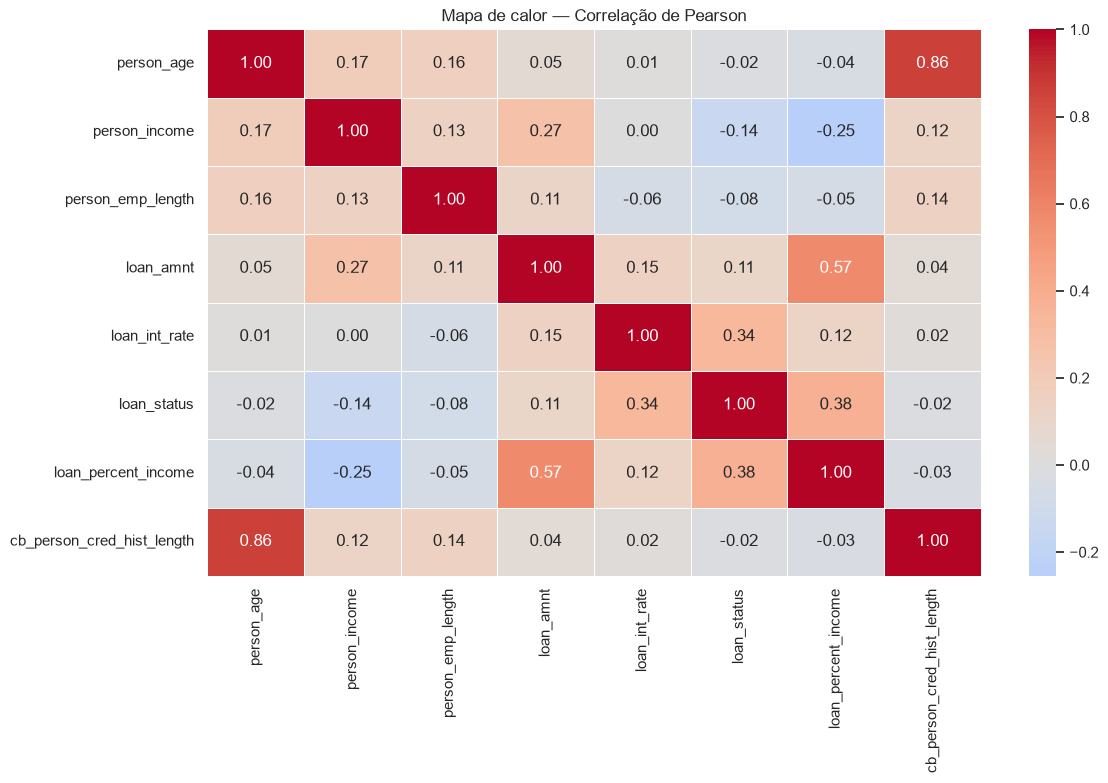

In [16]:
colunas_numericas_eda = (
    df_raw
    .select_dtypes(include='number')
    .columns
)

matriz_correlacao = (
    df_raw[colunas_numericas_eda]
    .corr(method='pearson')
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Mapa de calor — Correlação de Pearson')
plt.tight_layout()
plt.show()

O mapa de calor apresenta as correlações lineares entre as variáveis numéricas. Essa análise auxilia na identificação das relações entre renda, valor do empréstimo, percentual de renda comprometida, taxa de juros e variável-alvo. A correlação não representa causalidade, mas ajuda a compreender a estrutura dos dados e possíveis variáveis relevantes para os modelos.

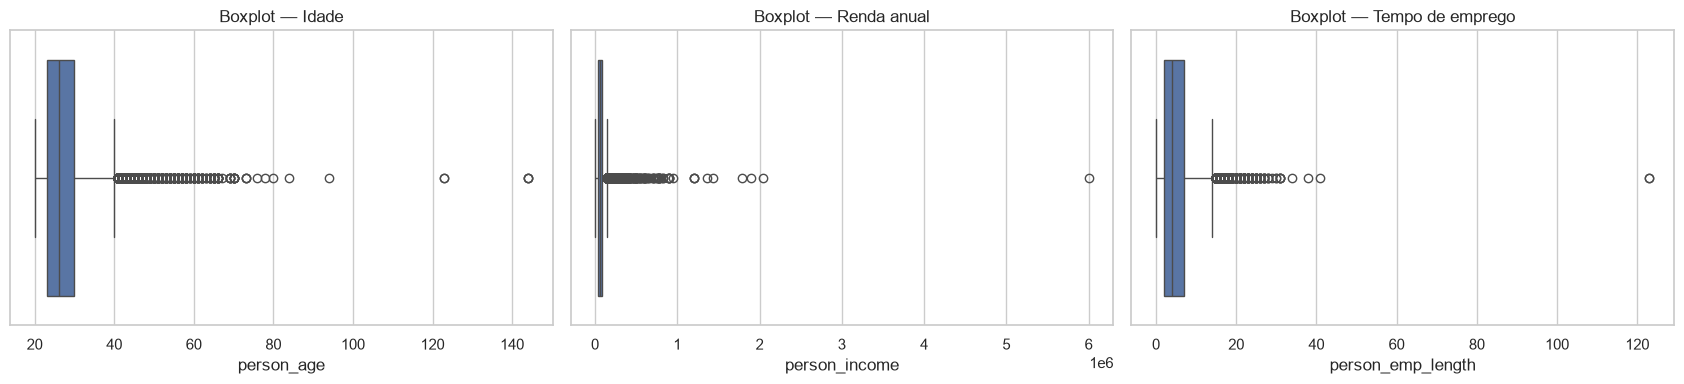

In [17]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4)
)

sns.boxplot(
    x=df_raw['person_age'],
    ax=axes[0]
)

axes[0].set_title('Boxplot — Idade')
axes[0].set_xlabel('person_age')

sns.boxplot(
    x=df_raw['person_income'],
    ax=axes[1]
)

axes[1].set_title('Boxplot — Renda anual')
axes[1].set_xlabel('person_income')

sns.boxplot(
    x=df_raw['person_emp_length'],
    ax=axes[2]
)

axes[2].set_title('Boxplot — Tempo de emprego')
axes[2].set_xlabel('person_emp_length')

plt.tight_layout()
plt.show()

Os boxplots evidenciam a presença de valores extremos nas variáveis de idade, renda e tempo de emprego. Alguns valores podem ser financeiramente plausíveis, como rendas elevadas, enquanto outros podem representar inconsistências, como idades superiores a 100 anos ou tempo de emprego incompatível com a idade do cliente. Por isso, registros logicamente impossíveis serão removidos, enquanto valores financeiros plausíveis receberão tratamento específico para o KNN.

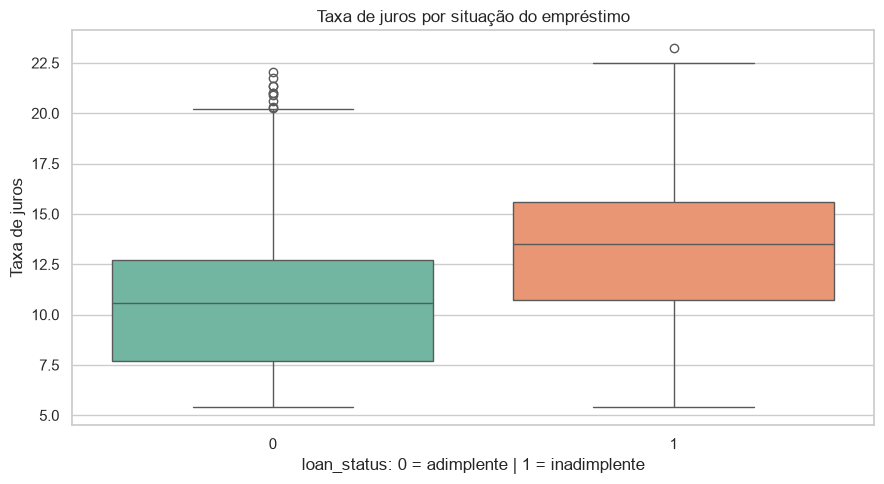

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_raw,
    x='loan_status',
    y='loan_int_rate',
    hue='loan_status',
    palette='Set2',
    legend=False
)

plt.title('Taxa de juros por situação do empréstimo')
plt.xlabel(
    'loan_status: 0 = adimplente | 1 = inadimplente'
)
plt.ylabel('Taxa de juros')
plt.tight_layout()
plt.show()

O gráfico compara a distribuição das taxas de juros entre clientes adimplentes e inadimplentes. É possível observar diferenças entre as classes, indicando que a taxa de juros pode contribuir para a capacidade preditiva dos modelos. Também existem valores ausentes nessa variável, que serão tratados posteriormente com a mediana.

# TRATAMENTO


In [7]:
# Remove linhas exatamente duplicadas.
df = df_raw.drop_duplicates().copy()

duplicatas_removidas = len(df_raw) - len(df)

# Regras determinísticas de consistência.
# Consideramos somente clientes entre 18 e 100 anos.
mascara_idade_valida = df['person_age'].between(18, 100)

# O tempo de emprego deve ser não negativo e não pode ultrapassar
# a idade disponível para trabalho.
# Os valores nulos são mantidos aqui, pois serão imputados depois.
mascara_emprego_valido = (
    df['person_emp_length'].isna()
    | (
        (df['person_emp_length'] >= 0)
        & (
            df['person_emp_length']
            <= df['person_age'] - 14
        )
    )
)

quantidade_antes_regras = len(df)

df = df.loc[
    mascara_idade_valida
    & mascara_emprego_valido
].copy()

inconsistencias_removidas = quantidade_antes_regras - len(df)

print(f'Duplicatas removidas: {duplicatas_removidas:,}')

print(
    f'Registros logicamente inconsistentes removidos: '
    f'{inconsistencias_removidas:,}'
)

print(
    f'Tamanho após a limpeza determinística: '
    f'{df.shape[0]:,} linhas e {df.shape[1]} colunas.'
)

Duplicatas removidas: 165
Registros logicamente inconsistentes removidos: 7
Tamanho após a limpeza determinística: 32,409 linhas e 12 colunas.


As linhas duplicadas foram removidas porque poderiam dar peso artificial a determinados clientes durante o treinamento. Também foram removidos apenas registros logicamente impossíveis: clientes menores de 18 anos, maiores de 100 anos, tempo de emprego negativo ou tempo de emprego superior ao período em que o cliente poderia trabalhar. Os valores ausentes foram preservados nessa etapa para serem tratados depois da separação entre treino e teste.

In [8]:
# Separação entre variáveis preditoras e variável-alvo.
X = df.drop(columns='loan_status')
y = df['loan_status'].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print('DISTRIBUIÇÃO ANTES DA DIVISÃO')

display(
    (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .rename('percentual_%')
    )
)

print('DISTRIBUIÇÃO NO TREINO')

display(
    (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .rename('percentual_%')
    )
)

print('DISTRIBUIÇÃO NO TESTE')

display(
    (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .rename('percentual_%')
    )
)

DISTRIBUIÇÃO ANTES DA DIVISÃO


loan_status
0   78.1300
1   21.8700
Name: percentual_%, dtype: float64

DISTRIBUIÇÃO NO TREINO


loan_status
0   78.1300
1   21.8700
Name: percentual_%, dtype: float64

DISTRIBUIÇÃO NO TESTE


loan_status
0   78.1200
1   21.8800
Name: percentual_%, dtype: float64

A variável-alvo foi separada das variáveis preditoras e os dados foram divididos em 80% para treino e 20% para teste. O parâmetro stratify=y preserva a proporção das classes nos dois conjuntos. O conjunto de teste permanecerá sem balanceamento e será utilizado apenas na avaliação final, simulando dados reais ainda não vistos pelos modelos.

In [20]:
colunas_numericas_originais = (
    X_train_raw
    .select_dtypes(include='number')
    .columns
    .tolist()
)

colunas_categoricas = (
    X_train_raw
    .select_dtypes(exclude='number')
    .columns
    .tolist()
)


# As medianas são calculadas somente no treino.
medianas_treino = (
    X_train_raw[colunas_numericas_originais]
    .median()
)


X_train = X_train_raw.copy()
X_test = X_test_raw.copy()


X_train[colunas_numericas_originais] = (
    X_train[colunas_numericas_originais]
    .fillna(medianas_treino)
)

X_test[colunas_numericas_originais] = (
    X_test[colunas_numericas_originais]
    .fillna(medianas_treino)
)


print('MEDIANAS APRENDIDAS SOMENTE NO TREINO')

display(
    medianas_treino[
        ['person_emp_length', 'loan_int_rate']
    ].to_frame('mediana_treino')
)


print(
    'Valores nulos restantes no treino:',
    int(X_train.isna().sum().sum())
)

print(
    'Valores nulos restantes no teste:',
    int(X_test.isna().sum().sum())
)


MEDIANAS APRENDIDAS SOMENTE NO TREINO


,mediana_treino
person_emp_length,4.0000
loan_int_rate,10.9900


Valores nulos restantes no treino: 0
Valores nulos restantes no teste: 0


Os valores ausentes de person_emp_length e loan_int_rate foram preenchidos utilizando a mediana. Essa técnica foi escolhida porque a mediana é menos influenciada por valores extremos do que a média. Para evitar vazamento de dados, as medianas foram calculadas exclusivamente no conjunto de treino e depois aplicadas ao conjunto de teste.

In [21]:
def adicionar_comprometimento_renda(
    dados: pd.DataFrame
) -> pd.DataFrame:
    """
    Cria a variável obrigatória:

    comprometimento_renda =
    (loan_amnt / person_income) * 100
    """

    resultado = dados.copy()

    # Evita divisão por zero.
    renda_segura = (
        resultado['person_income']
        .replace(0, np.nan)
    )

    resultado['comprometimento_renda'] = (
        resultado['loan_amnt']
        / renda_segura
    ) * 100

    # Remove possíveis valores infinitos.
    resultado['comprometimento_renda'] = (
        resultado['comprometimento_renda']
        .replace([np.inf, -np.inf], np.nan)
    )

    return resultado


X_train = adicionar_comprometimento_renda(
    X_train
)

X_test = adicionar_comprometimento_renda(
    X_test
)


# A mediana é aprendida somente no treino.
mediana_comprometimento = (
    X_train['comprometimento_renda']
    .median()
)


X_train['comprometimento_renda'] = (
    X_train['comprometimento_renda']
    .fillna(mediana_comprometimento)
)

X_test['comprometimento_renda'] = (
    X_test['comprometimento_renda']
    .fillna(mediana_comprometimento)
)


print('RESUMO DA NOVA VARIÁVEL')

display(
    X_train['comprometimento_renda']
    .describe()
    .to_frame()
    .T
)


print(
    'Valores nulos no treino:',
    X_train['comprometimento_renda']
    .isna()
    .sum()
)

print(
    'Valores infinitos no treino:',
    np.isinf(
        X_train['comprometimento_renda']
    ).sum()
)

RESUMO DA NOVA VARIÁVEL


,count,mean,std,min,25%,50%,75%,max
comprometimento_renda,"25,927.0000",17.0619,10.6964,0.2110,8.9770,14.8000,22.9301,83.0000


Valores nulos no treino: 0
Valores infinitos no treino: 0


Foi criada a variável numérica obrigatória comprometimento_renda, calculada pela divisão do valor do empréstimo pela renda anual do cliente, multiplicada por 100. Essa variável representa a porcentagem da renda comprometida pelo empréstimo. O cálculo foi protegido contra divisões por zero, valores ausentes e valores infinitos. Qualquer valor ausente gerado foi preenchido com a mediana aprendida somente no treino.

In [22]:
colunas_continuas = (
    colunas_numericas_originais
    + ['comprometimento_renda']
)


# Dados originais para a Árvore de Decisão.
X_train_tree_base = X_train.copy()
X_test_tree_base = X_test.copy()


# Cópias específicas para o KNN.
X_train_knn_base = X_train.copy()
X_test_knn_base = X_test.copy()


limites_clipping = {}


for coluna in colunas_continuas:

    limite_inferior = float(
        X_train[coluna].quantile(0.01)
    )

    limite_superior = float(
        X_train[coluna].quantile(0.99)
    )

    limites_clipping[coluna] = {
        'percentil_1': limite_inferior,
        'percentil_99': limite_superior
    }

    X_train_knn_base[coluna] = (
        X_train_knn_base[coluna]
        .astype(float)
        .clip(
            lower=limite_inferior,
            upper=limite_superior
        )
    )

    X_test_knn_base[coluna] = (
        X_test_knn_base[coluna]
        .astype(float)
        .clip(
            lower=limite_inferior,
            upper=limite_superior
        )
    )


limites_df = (
    pd.DataFrame(limites_clipping)
    .T
)


print(
    'LIMITES DE CLIPPING APRENDIDOS SOMENTE NO TREINO'
)

display(limites_df)

LIMITES DE CLIPPING APRENDIDOS SOMENTE NO TREINO


,percentil_1,percentil_99
person_age,21.0000,49.0000
person_income,"14,400.0000","227,500.0000"
person_emp_length,0.0000,17.0000
loan_amnt,"1,013.0000","29,000.0000"
loan_int_rate,5.4200,18.4300
loan_percent_income,0.0200,0.4900
cb_person_cred_hist_length,2.0000,17.0000
comprometimento_renda,2.0000,49.6628


Foram adotadas estratégias diferentes para os dois algoritmos. A Árvore de Decisão manteve os valores financeiros extremos, pois realiza cortes nas variáveis e é menos sensível à escala. O KNN recebeu uma versão com clipping entre os percentis 1 e 99, pois calcula distâncias e pode ser prejudicado por valores extremos. Os limites foram calculados somente no treino e aplicados posteriormente ao teste, evitando vazamento de dados.

In [23]:
try:
    encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        dtype=np.float64
    )

except TypeError:
    # Compatibilidade com versões anteriores.
    encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse=False,
        dtype=np.float64
    )


categoricas_train_encoded = (
    encoder.fit_transform(
        X_train[colunas_categoricas]
    )
)

categoricas_test_encoded = (
    encoder.transform(
        X_test[colunas_categoricas]
    )
)


nomes_dummies = (
    encoder
    .get_feature_names_out(colunas_categoricas)
    .tolist()
)


def combinar_numericas_e_categoricas(
    base: pd.DataFrame,
    categoricas_codificadas: np.ndarray
) -> pd.DataFrame:

    numericas = (
        base[colunas_continuas]
        .reset_index(drop=True)
    )

    dummies = pd.DataFrame(
        categoricas_codificadas,
        columns=nomes_dummies
    )

    return pd.concat(
        [numericas, dummies],
        axis=1
    )


X_train_tree = combinar_numericas_e_categoricas(
    X_train_tree_base,
    categoricas_train_encoded
)

X_test_tree = combinar_numericas_e_categoricas(
    X_test_tree_base,
    categoricas_test_encoded
)

X_train_knn = combinar_numericas_e_categoricas(
    X_train_knn_base,
    categoricas_train_encoded
)

X_test_knn = combinar_numericas_e_categoricas(
    X_test_knn_base,
    categoricas_test_encoded
)


# Reinicia os índices para manter o alinhamento.
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


print(
    f'Número final de variáveis preditoras: '
    f'{X_train_tree.shape[1]}'
)

print(
    'Todas as variáveis são numéricas:',
    all(
        np.issubdtype(tipo, np.number)
        for tipo in X_train_tree.dtypes
    )
)

Número final de variáveis preditoras: 27
Todas as variáveis são numéricas: True


As variáveis categóricas foram transformadas em formato numérico por meio do One-Hot Encoding. O encoder foi ajustado exclusivamente no conjunto de treino e apenas utilizado para transformar o teste. O parâmetro handle_unknown='ignore' impede erros caso uma categoria não observada no treino apareça no teste. Foram preparadas bases separadas para a Árvore de Decisão e para o KNN.

# BALANCEAMENTO DOS DADOS SOMENTE NO TREINO


In [24]:
print('CLASSES ANTES DO BALANCEAMENTO')

display(
    y_train
    .value_counts()
    .sort_index()
    .rename('quantidade')
)


balanceador = RandomUnderSampler(
    random_state=RANDOM_STATE
)


X_train_tree_bal, y_train_bal = (
    balanceador.fit_resample(
        X_train_tree,
        y_train
    )
)


# Recupera as linhas selecionadas pelo balanceador.
indices_balanceados = (
    balanceador.sample_indices_
)


# Utiliza exatamente os mesmos clientes no KNN.
X_train_knn_bal = (
    X_train_knn
    .iloc[indices_balanceados]
    .reset_index(drop=True)
)


X_train_tree_bal = (
    X_train_tree_bal
    .reset_index(drop=True)
)

y_train_bal = (
    y_train_bal
    .reset_index(drop=True)
)


print('CLASSES DEPOIS DO BALANCEAMENTO')

display(
    y_train_bal
    .value_counts()
    .sort_index()
    .rename('quantidade')
)


print(
    'Formato do treino balanceado:',
    X_train_tree_bal.shape
)

print(
    'Formato do teste preservado:',
    X_test_tree.shape
)

CLASSES ANTES DO BALANCEAMENTO


loan_status
0    20257
1     5670
Name: quantidade, dtype: int64

CLASSES DEPOIS DO BALANCEAMENTO


loan_status
0    5670
1    5670
Name: quantidade, dtype: int64

Formato do treino balanceado: (11340, 27)
Formato do teste preservado: (6482, 27)


Foi utilizado o RandomUnderSampler exclusivamente no conjunto de treino. A técnica reduz a quantidade de exemplos da classe majoritária até que as classes fiquem equilibradas. O conjunto de teste não foi balanceado, pois deve preservar a distribuição real dos dados. As mesmas linhas selecionadas foram utilizadas no treino da Árvore e do KNN, garantindo uma comparação justa entre os modelos.

In [25]:
scaler = StandardScaler()


X_train_knn_scaled = (
    X_train_knn_bal.copy()
)

X_test_knn_scaled = (
    X_test_knn.copy()
)


# Escala somente as variáveis contínuas.
X_train_knn_scaled[colunas_continuas] = (
    scaler.fit_transform(
        X_train_knn_bal[colunas_continuas]
    )
)

X_test_knn_scaled[colunas_continuas] = (
    scaler.transform(
        X_test_knn[colunas_continuas]
    )
)


print(
    'MÉDIAS DAS VARIÁVEIS CONTÍNUAS '
    'APÓS O ESCALONAMENTO'
)

display(
    X_train_knn_scaled[colunas_continuas]
    .mean()
    .round(4)
    .to_frame('media')
)


print(
    'A Árvore utilizará os dados balanceados '
    'sem aplicação do StandardScaler.'
)

MÉDIAS DAS VARIÁVEIS CONTÍNUAS APÓS O ESCALONAMENTO


,media
person_age,-0.0000
person_income,0.0000
person_emp_length,-0.0000
loan_amnt,-0.0000
loan_int_rate,-0.0000
loan_percent_income,0.0000
cb_person_cred_hist_length,0.0000
comprometimento_renda,0.0000


A Árvore utilizará os dados balanceados sem aplicação do StandardScaler.


O StandardScaler foi aplicado exclusivamente às variáveis contínuas utilizadas pelo KNN. O ajuste ocorreu apenas no treino balanceado por meio de fit_transform, enquanto o teste recebeu somente transform. As variáveis dummy não foram escaladas. A Árvore de Decisão foi treinada sem escalonamento, pois seus cortes são independentes da unidade de medida das variáveis.

In [26]:
def calcular_metricas(
    y_real,
    y_previsto
) -> dict:

    return {
        'accuracy': accuracy_score(
            y_real,
            y_previsto
        ),

        'balanced_accuracy': balanced_accuracy_score(
            y_real,
            y_previsto
        ),

        'precision_1': precision_score(
            y_real,
            y_previsto,
            zero_division=0
        ),

        'recall_1': recall_score(
            y_real,
            y_previsto,
            zero_division=0
        ),

        'f1_1': f1_score(
            y_real,
            y_previsto,
            zero_division=0
        ),

        'f2_1': fbeta_score(
            y_real,
            y_previsto,
            beta=2,
            zero_division=0
        )
    }


def montar_linha_resultado(
    parametro,
    metricas_treino,
    metricas_teste
) -> dict:

    linha = {
        'parametro': parametro
    }

    linha.update({
        f'treino_{nome}': valor
        for nome, valor
        in metricas_treino.items()
    })

    linha.update({
        f'teste_{nome}': valor
        for nome, valor
        in metricas_teste.items()
    })

    linha['gap_balanced_accuracy'] = (
        linha['treino_balanced_accuracy']
        - linha['teste_balanced_accuracy']
    )

    return linha

Foram criadas funções para calcular de maneira padronizada as métricas de treino e teste. Além da acurácia, foram avaliadas acurácia balanceada, precisão, recall, F1 e F2 da classe inadimplente. A métrica F2 atribui maior peso ao recall, sendo importante porque um falso negativo representa um cliente inadimplente classificado incorretamente como seguro. O gap entre treino e teste será utilizado para diagnosticar overfitting.

RESULTADOS DOS HIPERPARÂMETROS DO KNN


,k,treino_accuracy,treino_balanced_accuracy,treino_precision_1,treino_recall_1,treino_f1_1,treino_f2_1,teste_accuracy,teste_balanced_accuracy,teste_precision_1,teste_recall_1,teste_f1_1,teste_f2_1,gap_balanced_accuracy
0,3,0.8927,0.8927,0.9091,0.8727,0.8905,0.8797,0.8025,0.7916,0.5336,0.7722,0.6311,0.7088,0.1011
1,5,0.8659,0.8659,0.8897,0.8353,0.8616,0.8456,0.8119,0.7946,0.5506,0.7638,0.6399,0.7089,0.0713
2,7,0.8525,0.8525,0.8800,0.8162,0.8469,0.8282,0.8255,0.8086,0.5747,0.7786,0.6613,0.7270,0.0439
3,9,0.8445,0.8445,0.8760,0.8026,0.8377,0.8163,0.8246,0.8060,0.5735,0.7729,0.6585,0.7227,0.0385


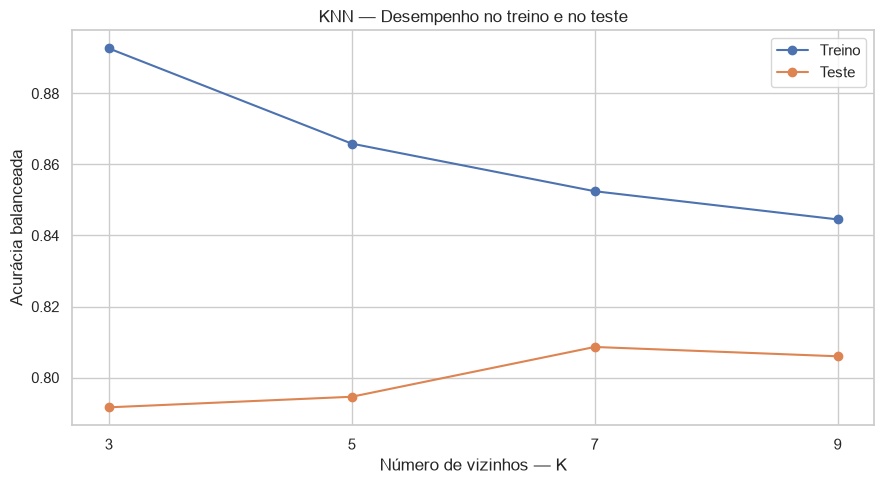

In [27]:
valores_k = [3, 5, 7, 9]

linhas_resultados_knn = []


for k in valores_k:

    modelo_knn = KNeighborsClassifier(
        n_neighbors=k,
        algorithm='kd_tree',
        n_jobs=1
    )

    modelo_knn.fit(
        X_train_knn_scaled,
        y_train_bal
    )

    previsao_treino = modelo_knn.predict(
        X_train_knn_scaled
    )

    previsao_teste = modelo_knn.predict(
        X_test_knn_scaled
    )

    metricas_treino = calcular_metricas(
        y_train_bal,
        previsao_treino
    )

    metricas_teste = calcular_metricas(
        y_test,
        previsao_teste
    )

    linhas_resultados_knn.append(
        montar_linha_resultado(
            parametro=k,
            metricas_treino=metricas_treino,
            metricas_teste=metricas_teste
        )
    )


resultados_knn = (
    pd.DataFrame(linhas_resultados_knn)
    .rename(columns={'parametro': 'k'})
)


print('RESULTADOS DOS HIPERPARÂMETROS DO KNN')

display(
    resultados_knn.round(4)
)


plt.figure(figsize=(9, 5))

plt.plot(
    resultados_knn['k'],
    resultados_knn['treino_balanced_accuracy'],
    marker='o',
    label='Treino'
)

plt.plot(
    resultados_knn['k'],
    resultados_knn['teste_balanced_accuracy'],
    marker='o',
    label='Teste'
)

plt.xticks(valores_k)
plt.xlabel('Número de vizinhos — K')
plt.ylabel('Acurácia balanceada')
plt.title('KNN — Desempenho no treino e no teste')
plt.legend()
plt.tight_layout()
plt.show()

Foram testados quatro valores distintos do parâmetro n_neighbors: 3, 5, 7 e 9. Para cada configuração, foram calculadas métricas no treino e no teste. Essa comparação permite identificar configurações que apresentam ótimo desempenho no treino, mas perda significativa no teste, indicando overfitting. A acurácia balanceada foi utilizada no gráfico por considerar igualmente as duas classes.

RESULTADOS DOS HIPERPARÂMETROS DA ÁRVORE DE DECISÃO


,max_depth,treino_accuracy,treino_balanced_accuracy,treino_precision_1,treino_recall_1,treino_f1_1,treino_f2_1,teste_accuracy,teste_balanced_accuracy,teste_precision_1,teste_recall_1,teste_f1_1,teste_f2_1,gap_balanced_accuracy
0,3.0000,0.8066,0.8066,0.9109,0.6797,0.7785,0.7161,0.8798,0.8121,0.7415,0.6918,0.7158,0.7012,-0.0055
1,5.0000,0.8323,0.8323,0.9192,0.7286,0.8129,0.7601,0.8900,0.8367,0.7520,0.7419,0.7469,0.7439,-0.0044
2,7.0000,0.8446,0.8446,0.9177,0.7571,0.8297,0.7846,0.8886,0.8434,0.7371,0.7630,0.7498,0.7577,0.0012
3,9.0000,0.8628,0.8628,0.9426,0.7727,0.8492,0.8016,0.8948,0.8489,0.7556,0.7673,0.7614,0.7649,0.0139
4,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.8156,0.8198,0.5525,0.8272,0.6625,0.7524,0.1802


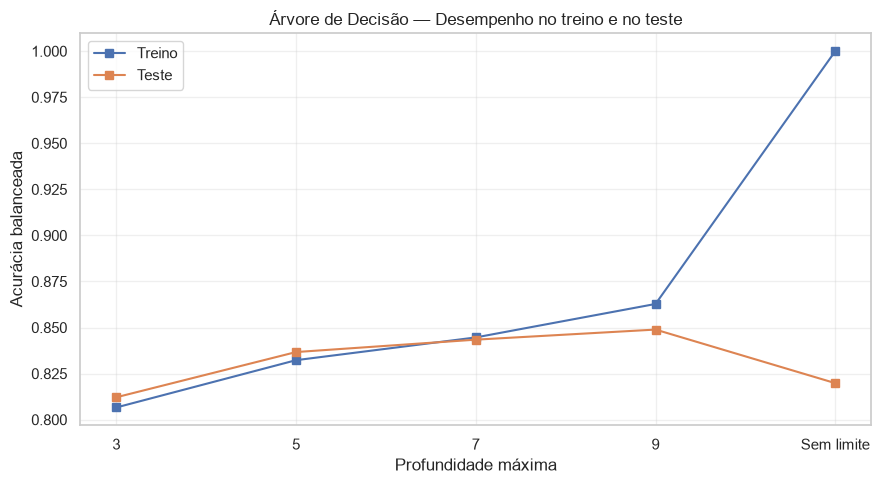

In [33]:
valores_profundidade = [
    3,
    5,
    7,
    9,
    None
]

linhas_resultados_arvore = []


for profundidade in valores_profundidade:

    modelo_arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=RANDOM_STATE
    )

    modelo_arvore.fit(
        X_train_tree_bal,
        y_train_bal
    )

    previsao_treino = modelo_arvore.predict(
        X_train_tree_bal
    )

    previsao_teste = modelo_arvore.predict(
        X_test_tree
    )

    metricas_treino = calcular_metricas(
        y_train_bal,
        previsao_treino
    )

    metricas_teste = calcular_metricas(
        y_test,
        previsao_teste
    )

    linhas_resultados_arvore.append(
        montar_linha_resultado(
            parametro=profundidade,
            metricas_treino=metricas_treino,
            metricas_teste=metricas_teste
        )
    )


resultados_arvore = (
    pd.DataFrame(linhas_resultados_arvore)
    .rename(
        columns={
            'parametro': 'max_depth'
        }
    )
)


print(
    'RESULTADOS DOS HIPERPARÂMETROS '
    'DA ÁRVORE DE DECISÃO'
)

display(
    resultados_arvore.round(4)
)


rotulos_profundidade = (
    resultados_arvore['max_depth']
    .astype(str)
)


# Cria posições numéricas para o eixo X.
posicoes_x = np.arange(
    len(resultados_arvore)
)

# Cria rótulos de texto sem misturar números, NaN e None.
rotulos_profundidade = []

for profundidade in resultados_arvore['max_depth']:

    if pd.isna(profundidade):
        rotulos_profundidade.append('Sem limite')

    else:
        rotulos_profundidade.append(
            str(int(profundidade))
        )


plt.figure(figsize=(9, 5))


plt.plot(
    posicoes_x,
    resultados_arvore[
        'treino_balanced_accuracy'
    ].to_numpy(dtype=float),
    marker='s',
    label='Treino'
)


plt.plot(
    posicoes_x,
    resultados_arvore[
        'teste_balanced_accuracy'
    ].to_numpy(dtype=float),
    marker='s',
    label='Teste'
)


plt.xticks(
    posicoes_x,
    rotulos_profundidade
)

plt.xlabel('Profundidade máxima')
plt.ylabel('Acurácia balanceada')

plt.title(
    'Árvore de Decisão — '
    'Desempenho no treino e no teste'
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Foram testadas as profundidades 3, 5, 7, 9 e uma árvore sem limite de profundidade, representada por None. A profundidade controla a complexidade do modelo. Árvores muito rasas podem sofrer underfitting, enquanto árvores ilimitadas podem memorizar o treino e sofrer overfitting. A comparação entre treino e teste permite selecionar uma profundidade com melhor capacidade de generalização.

In [29]:
def selecionar_melhor_configuracao(
    resultados: pd.DataFrame
) -> pd.Series:
    """
    Seleciona configurações com gap máximo de 0.10.

    Depois prioriza:
    1. maior F2 no teste;
    2. maior recall no teste;
    3. menor gap entre treino e teste.
    """

    candidatas = resultados[
        resultados['gap_balanced_accuracy']
        <= 0.10
    ].copy()

    if candidatas.empty:
        candidatas = resultados.copy()

    melhor_linha = candidatas.sort_values(
        by=[
            'teste_f2_1',
            'teste_recall_1',
            'gap_balanced_accuracy'
        ],
        ascending=[
            False,
            False,
            True
        ]
    ).iloc[0]

    return melhor_linha


melhor_linha_knn = (
    selecionar_melhor_configuracao(
        resultados_knn
    )
)

melhor_linha_arvore = (
    selecionar_melhor_configuracao(
        resultados_arvore
    )
)


melhor_k = int(
    melhor_linha_knn['k']
)


melhor_profundidade = (
    melhor_linha_arvore['max_depth']
)


if pd.notna(melhor_profundidade):
    melhor_profundidade = int(
        melhor_profundidade
    )
else:
    melhor_profundidade = None


print(
    f'Melhor K do KNN: '
    f'{melhor_k}'
)

print(
    f'Melhor profundidade da Árvore: '
    f'{melhor_profundidade}'
)

print(
    f"Gap do melhor KNN: "
    f"{melhor_linha_knn['gap_balanced_accuracy']:.4f}"
)

print(
    f"Gap da melhor Árvore: "
    f"{melhor_linha_arvore['gap_balanced_accuracy']:.4f}"
)


linha_arvore_sem_limite = (
    resultados_arvore[
        resultados_arvore[
            'max_depth'
        ].isna()
    ]
    .iloc[0]
)


print('\nDIAGNÓSTICO DA ÁRVORE SEM LIMITE')

print(
    f"Acurácia balanceada no treino: "
    f"{linha_arvore_sem_limite['treino_balanced_accuracy']:.4f}"
)

print(
    f"Acurácia balanceada no teste: "
    f"{linha_arvore_sem_limite['teste_balanced_accuracy']:.4f}"
)

print(
    f"Gap entre treino e teste: "
    f"{linha_arvore_sem_limite['gap_balanced_accuracy']:.4f}"
)

Melhor K do KNN: 7
Melhor profundidade da Árvore: 9
Gap do melhor KNN: 0.0439
Gap da melhor Árvore: 0.0139

DIAGNÓSTICO DA ÁRVORE SEM LIMITE
Acurácia balanceada no treino: 1.0000
Acurácia balanceada no teste: 0.8198
Gap entre treino e teste: 0.1802


A seleção dos melhores hiperparâmetros foi automatizada. Primeiramente, foram evitadas configurações com diferença de acurácia balanceada superior a 0,10 entre treino e teste. Entre as configurações restantes, foi priorizado o maior F2 no teste, seguido pelo maior recall e menor gap. A árvore sem limite apresentou desempenho perfeito no treino e queda significativa no teste, caracterizando overfitting. A profundidade limitada oferece melhor generalização.

In [30]:
knn_final = KNeighborsClassifier(
    n_neighbors=melhor_k,
    algorithm='kd_tree',
    n_jobs=1
)

knn_final.fit(
    X_train_knn_scaled,
    y_train_bal
)

prev_knn = knn_final.predict(
    X_test_knn_scaled
)


arvore_final = DecisionTreeClassifier(
    max_depth=melhor_profundidade,
    random_state=RANDOM_STATE
)

arvore_final.fit(
    X_train_tree_bal,
    y_train_bal
)

prev_arvore = arvore_final.predict(
    X_test_tree
)


print(
    f'CLASSIFICATION REPORT — '
    f'KNN COM K={melhor_k}'
)

print(
    classification_report(
        y_test,
        prev_knn,
        digits=4,
        zero_division=0
    )
)


print(
    f'CLASSIFICATION REPORT — '
    f'ÁRVORE COM PROFUNDIDADE '
    f'{melhor_profundidade}'
)

print(
    classification_report(
        y_test,
        prev_arvore,
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT — KNN COM K=7
              precision    recall  f1-score   support

           0     0.9312    0.8387    0.8825      5064
           1     0.5747    0.7786    0.6613      1418

    accuracy                         0.8255      6482
   macro avg     0.7529    0.8086    0.7719      6482
weighted avg     0.8532    0.8255    0.8341      6482

CLASSIFICATION REPORT — ÁRVORE COM PROFUNDIDADE 9
              precision    recall  f1-score   support

           0     0.9345    0.9305    0.9325      5064
           1     0.7556    0.7673    0.7614      1418

    accuracy                         0.8948      6482
   macro avg     0.8451    0.8489    0.8469      6482
weighted avg     0.8954    0.8948    0.8951      6482



Os modelos finais foram treinados utilizando as configurações selecionadas na etapa anterior. O KNN utilizou os dados balanceados, tratados e escalonados. A Árvore utilizou os dados balanceados sem escalonamento. Os relatórios apresentam precisão, recall, F1 e suporte para as duas classes, permitindo avaliar especificamente a capacidade de identificar clientes inadimplentes.

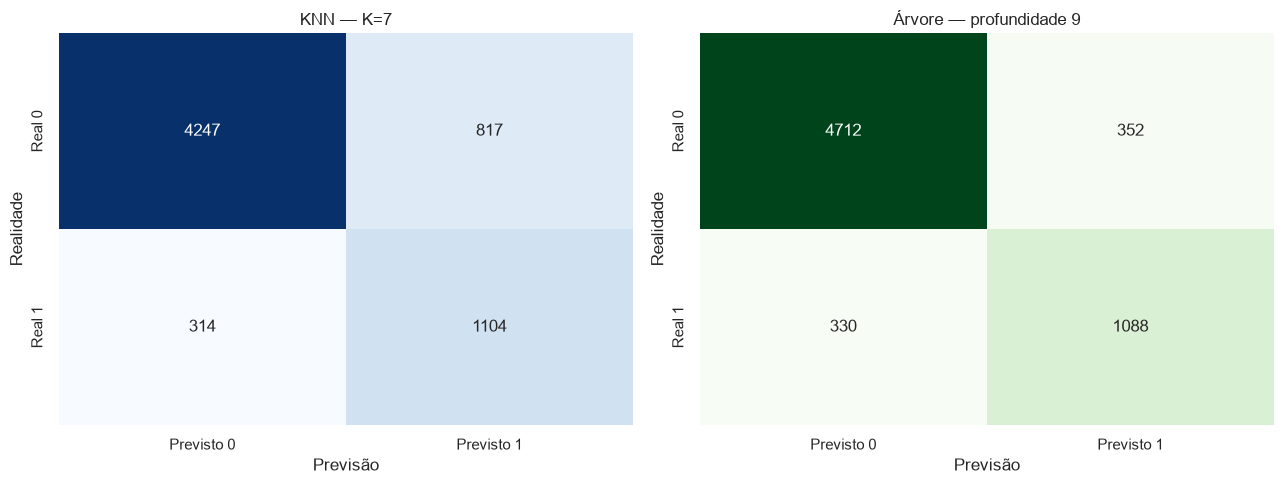

In [31]:
cm_knn = confusion_matrix(
    y_test,
    prev_knn
)

cm_arvore = confusion_matrix(
    y_test,
    prev_arvore
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=[
        'Previsto 0',
        'Previsto 1'
    ],
    yticklabels=[
        'Real 0',
        'Real 1'
    ]
)

axes[0].set_title(
    f'KNN — K={melhor_k}'
)

axes[0].set_xlabel('Previsão')
axes[0].set_ylabel('Realidade')


sns.heatmap(
    cm_arvore,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    ax=axes[1],
    xticklabels=[
        'Previsto 0',
        'Previsto 1'
    ],
    yticklabels=[
        'Real 0',
        'Real 1'
    ]
)

axes[1].set_title(
    f'Árvore — profundidade '
    f'{melhor_profundidade}'
)

axes[1].set_xlabel('Previsão')
axes[1].set_ylabel('Realidade')


plt.tight_layout()
plt.show()

As matrizes de confusão apresentam os acertos e erros de cada modelo. O falso positivo ocorre quando um bom pagador é classificado como inadimplente, podendo levar à rejeição de um cliente confiável. O falso negativo ocorre quando um inadimplente é classificado como seguro, podendo provocar prejuízo financeiro ao banco. A comparação das matrizes permite avaliar não apenas a quantidade total de acertos, mas principalmente o tipo de erro co

In [32]:
def criar_resumo_modelo(
    nome_modelo,
    y_real,
    y_previsto
) -> dict:

    tn, fp, fn, tp = confusion_matrix(
        y_real,
        y_previsto
    ).ravel()

    metricas = calcular_metricas(
        y_real,
        y_previsto
    )

    return {
        'modelo': nome_modelo,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'accuracy': metricas['accuracy'],
        'balanced_accuracy': (
            metricas['balanced_accuracy']
        ),
        'precision_1': metricas['precision_1'],
        'recall_1': metricas['recall_1'],
        'f1_1': metricas['f1_1'],
        'f2_1': metricas['f2_1']
    }


comparacao_final = pd.DataFrame([
    criar_resumo_modelo(
        f'KNN — K={melhor_k}',
        y_test,
        prev_knn
    ),

    criar_resumo_modelo(
        (
            f'Árvore — profundidade '
            f'{melhor_profundidade}'
        ),
        y_test,
        prev_arvore
    )
])


print('COMPARAÇÃO FINAL DOS MODELOS')

display(
    comparacao_final.round(4)
)


# Cenário financeiro ilustrativo.
CUSTO_FP_ILUSTRATIVO = 1
CUSTO_FN_ILUSTRATIVO = 5


comparacao_negocio = (
    comparacao_final[
        ['modelo', 'FP', 'FN']
    ]
    .copy()
)


comparacao_negocio[
    'custo_relativo_ilustrativo'
] = (
    comparacao_negocio['FP']
    * CUSTO_FP_ILUSTRATIVO
    +
    comparacao_negocio['FN']
    * CUSTO_FN_ILUSTRATIVO
)


print('COMPARAÇÃO DO CUSTO DOS ERROS')

display(comparacao_negocio)


linha_knn = comparacao_final.iloc[0]
linha_arvore = comparacao_final.iloc[1]


diferenca_fp = (
    linha_knn['FP']
    - linha_arvore['FP']
)

diferenca_fn = (
    linha_arvore['FN']
    - linha_knn['FN']
)


if diferenca_fp > 0 and diferenca_fn > 0:

    razao_equilibrio = (
        diferenca_fp / diferenca_fn
    )

    print(
        f'O KNN evita '
        f'{int(diferenca_fn)} falsos negativos '
        f'em comparação com a Árvore.'
    )

    print(
        f'Porém, o KNN gera '
        f'{int(diferenca_fp)} falsos positivos '
        f'adicionais.'
    )

    print(
        f'O KNN somente teria menor custo '
        f'se um falso negativo custasse mais de '
        f'{razao_equilibrio:.2f} falsos positivos.'
    )


modelo_recomendado = (
    comparacao_negocio
    .sort_values(
        'custo_relativo_ilustrativo'
    )
    .iloc[0]['modelo']
)


print(
    f'\nMODELO RECOMENDADO: '
    f'{modelo_recomendado}'
)

COMPARAÇÃO FINAL DOS MODELOS


,modelo,TN,FP,FN,TP,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,f2_1
0,KNN — K=7,4247,817,314,1104,0.8255,0.8086,0.5747,0.7786,0.6613,0.7270
1,Árvore — profundidade 9,4712,352,330,1088,0.8948,0.8489,0.7556,0.7673,0.7614,0.7649


COMPARAÇÃO DO CUSTO DOS ERROS


,modelo,FP,FN,custo_relativo_ilustrativo
0,KNN — K=7,817,314,2387
1,Árvore — profundidade 9,352,330,2002


O KNN evita 16 falsos negativos em comparação com a Árvore.
Porém, o KNN gera 465 falsos positivos adicionais.
O KNN somente teria menor custo se um falso negativo custasse mais de 29.06 falsos positivos.

MODELO RECOMENDADO: Árvore — profundidade 9


Na análise financeira, um falso positivo representa um cliente adimplente classificado como arriscado, fazendo o banco perder uma possível operação de crédito. Já um falso negativo representa um cliente inadimplente classificado como seguro, podendo resultar na perda do capital emprestado. Como a base não apresenta valores financeiros reais para cada erro, foi criado um cenário ilustrativo e transparente em que o falso negativo custa cinco vezes mais que o falso positivo.

A Árvore de Decisão foi recomendada porque apresentou melhor equilíbrio entre acurácia, precisão, recall, F1, F2, capacidade de generalização e quantidade de falsos positivos. O KNN identificou alguns inadimplentes adicionais, mas classificou incorretamente uma quantidade muito maior de bons pagadores como arriscados. A decisão final deve considerar os custos reais do banco antes de uma implantação em produção.